# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [38]:
R = 1.
r = 0.6

NGSOLVE = True

lc = 0.6

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    #mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [39]:
mesh.n_triangles

26

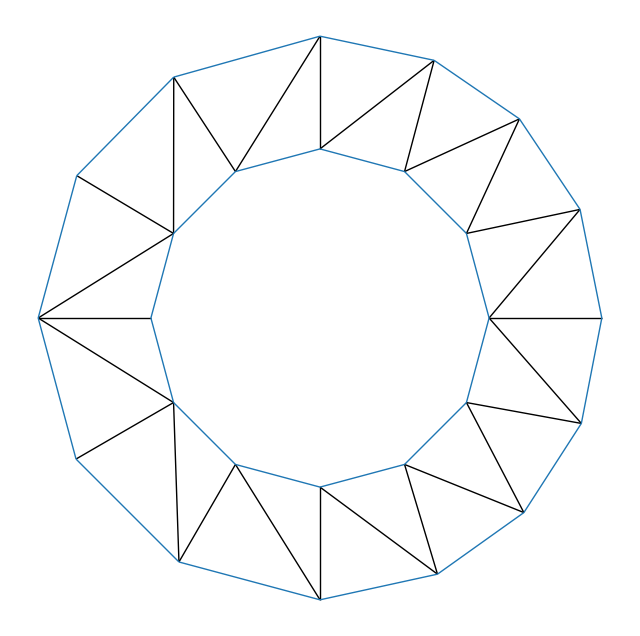

In [40]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [41]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [42]:
mesh.curve_region(Regions.SIGMA, radius=R)
mesh.curve_region(Regions.d_Omega, radius=r)


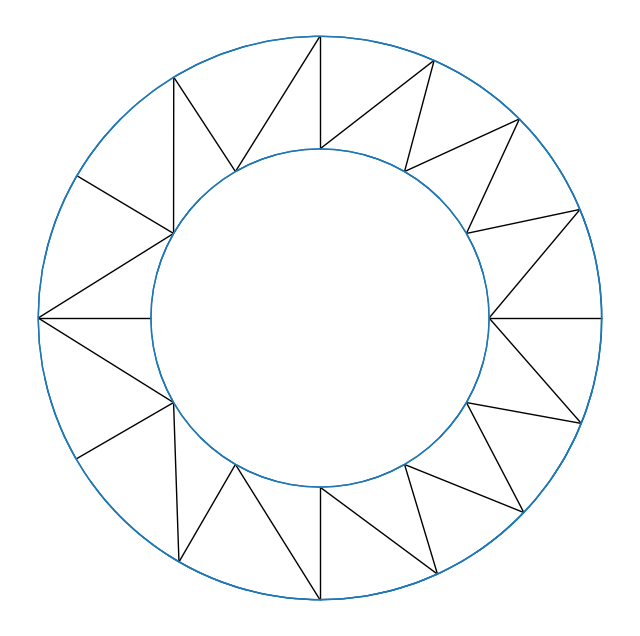

In [43]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [44]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [45]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
#boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [46]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [47]:
from cases.open_space.kernels import NtDLocal_circle, NtDNonLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [48]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
a = 0.5
b = 0.5
d1 = 0.5
d2 = 0.5
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal_circle(R=R, d_2=d2, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal_circle(d_2=d2, NtD_modes=5, data = None)})

We should also choose a local basis

In [69]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 11
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [70]:
basis.N_DOF

286

In [71]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [72]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [73]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [74]:
A = P.assemble_LHS()

Interior: 100%|██████████| 26/26 [00:01<00:00, 23.25edge/s]


assembling local operators
region: Sigma


100%|██████████| 14/14 [00:01<00:00,  7.13edge/s]


region: d_Omega


100%|██████████| 12/12 [00:01<00:00,  7.90edge/s]


assembling non-local operators


NtD: 100%|██████████| 14/14 [28:29<00:00, 122.12s/edge]


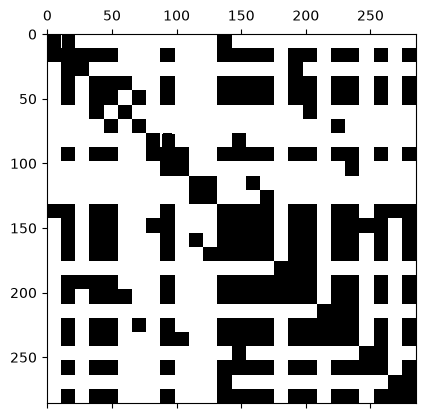

In [76]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [77]:
b = P.assemble_RHS()

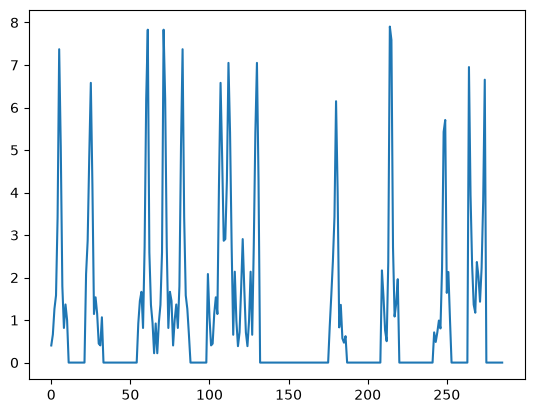

In [78]:
import numpy as np 
plt.plot(np.abs(b))

In [79]:
P.solve()

In [80]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 9.35995740e+01-3.68037905e+02j,  3.10132602e+02-6.04356492e+02j,
         5.24509873e+02-7.44988323e+02j, -9.72248427e+02-1.71120013e+02j,
         1.26560135e+02+2.30371089e+02j,  9.45599365e+01+6.86636831e+02j,
        -8.84529165e+01+2.87837620e+02j, -2.77552009e+02-1.90343250e+00j,
         9.51916859e+01-1.19020432e+02j,  1.00311481e+02+1.05683513e+02j,
         2.32430956e+02-1.34682197e+02j],
       [ 1.06922811e+02-4.19705842e+01j,  1.31981122e+02+2.34482923e+01j,
         7.63793554e+01+5.46469358e+00j, -1.89357237e+01-1.03466134e+01j,
        -7.15990896e-01-5.77370164e+01j, -8.70009164e+00-5.84709287e+01j,
        -1.80194896e+01-4.19918045e+01j, -1.65708393e+01-3.54115622e+01j,
        -1.43026230e+01-9.39239971e+00j, -2.69194111e+00+7.38131323e-01j,
         1.35360334e+01+1.94290087e+01j],
       [ 1.39824916e+03+2.69621638e+03j,  9.28401769e+02+3.11791449e+03j,
         1.68836251e+03+2.34460467e+03j,  9.59759164e+02-1.21364311e+03j,
         1.10009737e+03+9.86

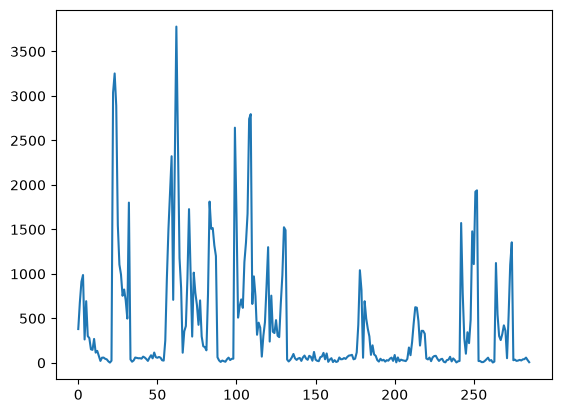

In [81]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [82]:
import numpy as np
N = 200
rs = np.linspace(r, R, N)
#rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.09986915899354),
 np.float64(1.100062304173604),
 np.float64(-1.099965731583572),
 np.float64(1.099965731583572))

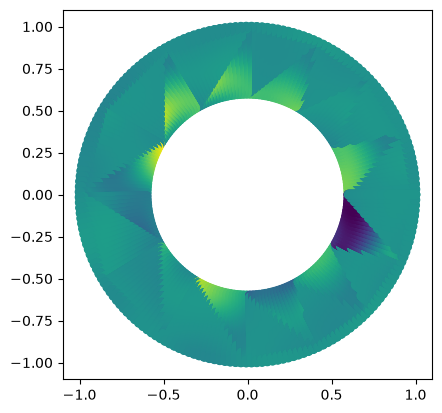

In [83]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")